# Exploratory Data Analysis — Titanic Dataset

Dataset: `Titanic.csv` — 712 passenger records with survival outcome, class, gender, age, family size, fare, and port of embarkation.

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
import warnings
warnings.filterwarnings("ignore")

In [1]:
df = pd.read_csv('Titanic.csv')
df.head()

  Survived       Pclass  Gender   Age  Family     Fare     Embarked
0       No  Third class    Male  22.0       1   7.2500  Southampton
1      Yes  First class  Female  38.0       1  71.2833    Cherbourg
2      Yes  Third class  Female  26.0       0   7.9250  Southampton
3      Yes  First class  Female  35.0       1  53.1000  Southampton
4       No  Third class    Male  35.0       0   8.0500  Southampton

## 2. Basic Structure

In [1]:
df.shape

(712, 7)

In [1]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    str    
 1   Pclass    712 non-null    str    
 2   Gender    712 non-null    str    
 3   Age       712 non-null    float64
 4   Family    712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Embarked  712 non-null    str    
dtypes: float64(2), int64(1), str(4)
memory usage: 39.1 KB


In [1]:
df.describe()

              Age      Family        Fare
count  712.000000  712.000000  712.000000
mean    29.644663    0.946629   34.567251
std     14.487814    1.485027   52.938648
min      1.000000    0.000000    0.000000
25%     20.000000    0.000000    8.050000
50%     28.000000    0.000000   15.645850
75%     38.000000    1.000000   33.000000
max     80.000000    7.000000  512.329200

## 3. Data Quality Checks

In [1]:
df.isnull().sum()

Survived    0
Pclass      0
Gender      0
Age         0
Family      0
Fare        0
Embarked    0

In [1]:
df.duplicated().sum()

38

No missing values and no duplicate rows. However, two categorical columns have data-entry inconsistencies worth cleaning up before analysis:

In [1]:
df['Pclass'].unique()

['Third class', 'First class', 'Second Class']

In [1]:
df['Embarked'].unique()

['Southampton', 'Cherbourg', 'Queesntown']

`Pclass` has inconsistent capitalization (`'Second Class'` vs. `'First class'`/`'Third class'`), and `Embarked` has a typo (`'Queesntown'` should be `'Queenstown'`). Both are fixed below.

In [1]:
df['Pclass'] = df['Pclass'].str.replace('Second Class', 'Second class', regex=False)
df['Embarked'] = df['Embarked'].replace('Queesntown', 'Queenstown')

df['Pclass'].unique(), df['Embarked'].unique()

['Third class', 'First class', 'Second class'], ['Southampton', 'Cherbourg', 'Queenstown']

## 4. Overall Survival

In [1]:
df['Survived_num'] = (df['Survived'] == 'Yes').astype(int)

overall_rate = df['Survived_num'].mean()
print(f"Overall survival rate: {overall_rate:.2%}")
print(f"Total passengers: {len(df)}")
print(f"Survived: {df['Survived_num'].sum()}")
print(f"Did not survive: {(df['Survived_num']==0).sum()}")

Overall survival rate: 40.45%
Total passengers: 712
Survived: 288
Did not survive: 424

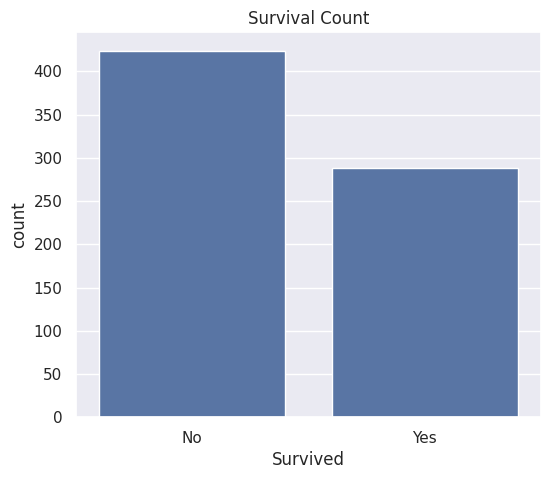

In [1]:
plt.figure(figsize=(6,5))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

## 5. Survival by Class, Gender, and Port

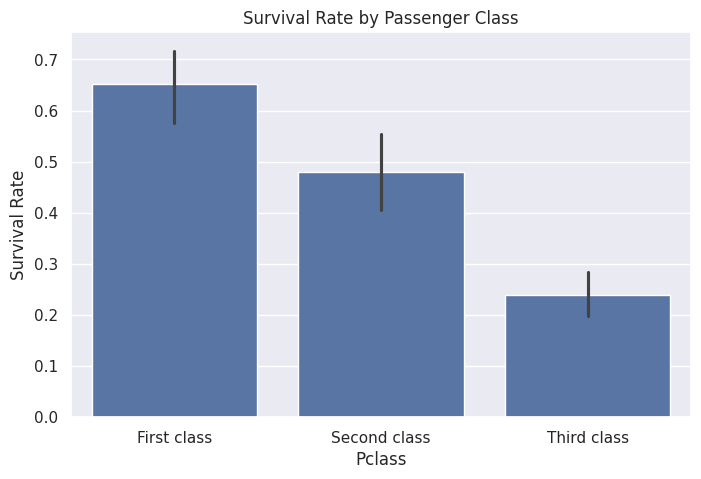

In [1]:
pclass_order = ['First class', 'Second class', 'Third class']
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y='Survived_num', data=df, order=pclass_order)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

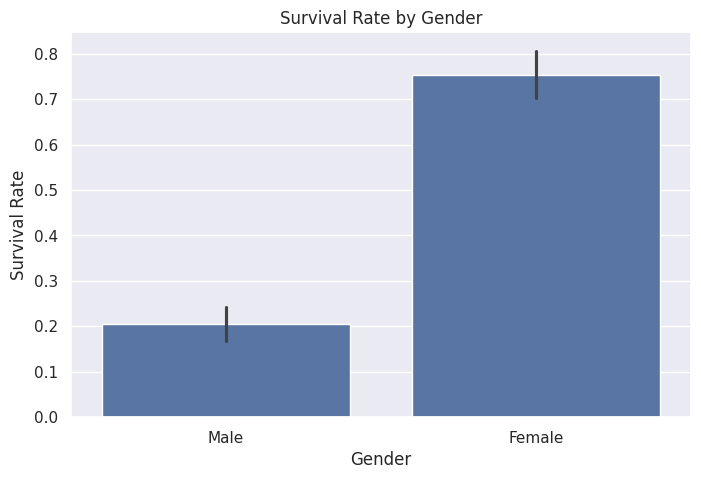

In [1]:
plt.figure(figsize=(8,5))
sns.barplot(x='Gender', y='Survived_num', data=df)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

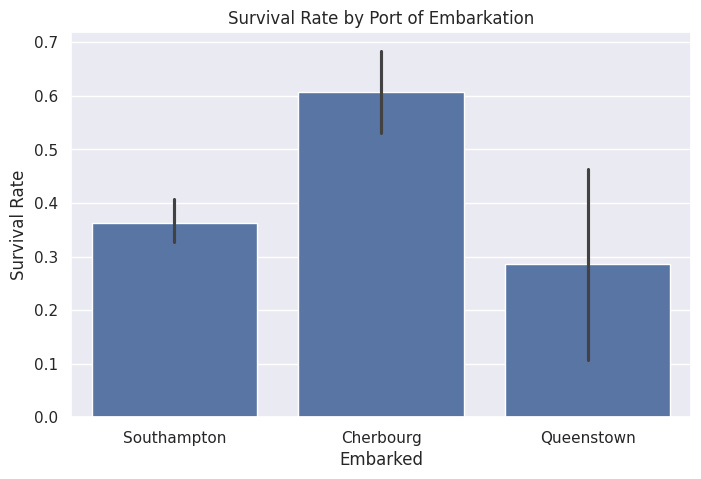

In [1]:
plt.figure(figsize=(8,5))
sns.barplot(x='Embarked', y='Survived_num', data=df)
plt.title('Survival Rate by Port of Embarkation')
plt.ylabel('Survival Rate')
plt.show()

## 6. Age & Fare Distributions

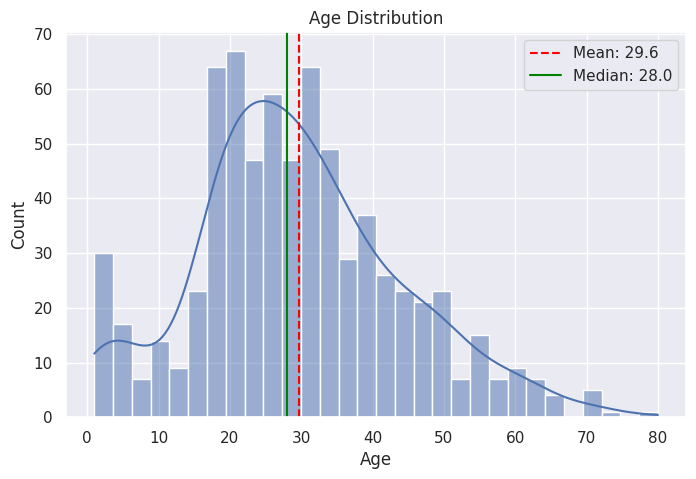

In [1]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True, bins=30)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
plt.axvline(df['Age'].median(), color='green', linestyle='-', label=f"Median: {df['Age'].median():.1f}")
plt.title('Age Distribution')
plt.legend()
plt.show()

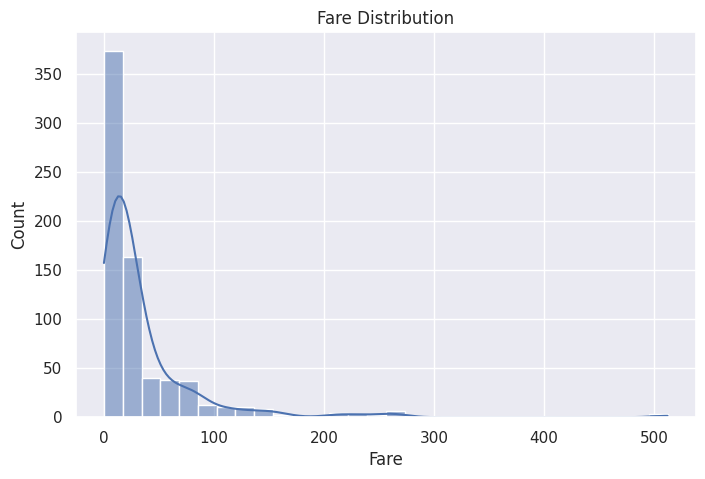

In [1]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], kde=True, bins=30)
plt.title('Fare Distribution')
plt.show()

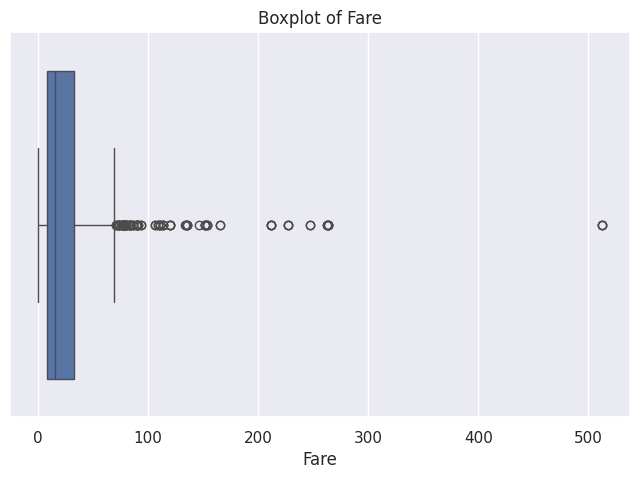

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare')
plt.show()

Fare is heavily right-skewed with a handful of very high-fare outliers — consistent with a small number of first-class passengers paying substantially more than everyone else.

## 7. Age, Fare, and Family Size vs Survival

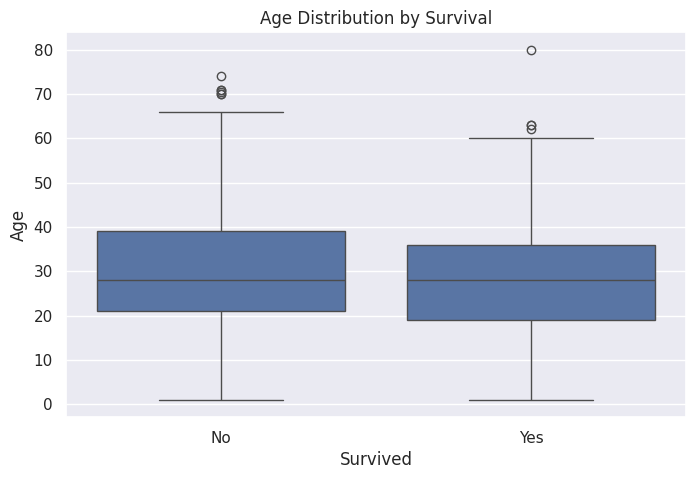

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival')
plt.show()

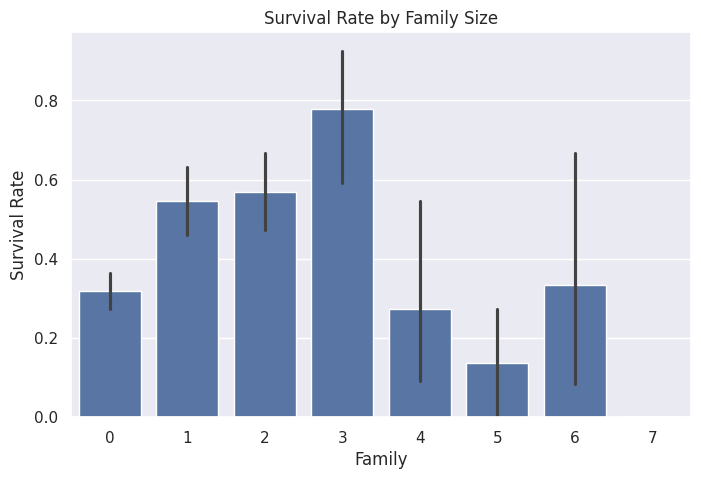

In [1]:
plt.figure(figsize=(8,5))
sns.barplot(x='Family', y='Survived_num', data=df)
plt.title('Survival Rate by Family Size')
plt.ylabel('Survival Rate')
plt.show()

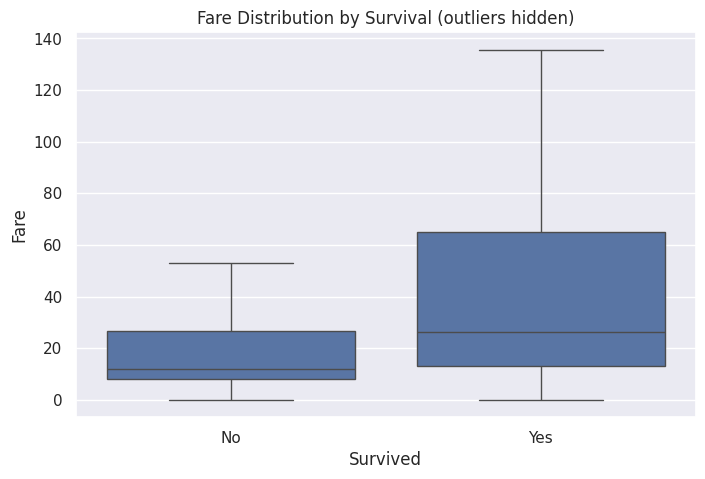

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Fare', data=df, showfliers=False)
plt.title('Fare Distribution by Survival (outliers hidden)')
plt.show()

## 8. Class × Gender Interaction

In [1]:
pivot = df.pivot_table(values='Survived_num', index='Pclass', columns='Gender', aggfunc='mean')
pivot = pivot.reindex(pclass_order)
pivot

Gender          Female      Male
Pclass                          
First class   0.963855  0.396040
Second class  0.918919  0.151515
Third class   0.460784  0.150198

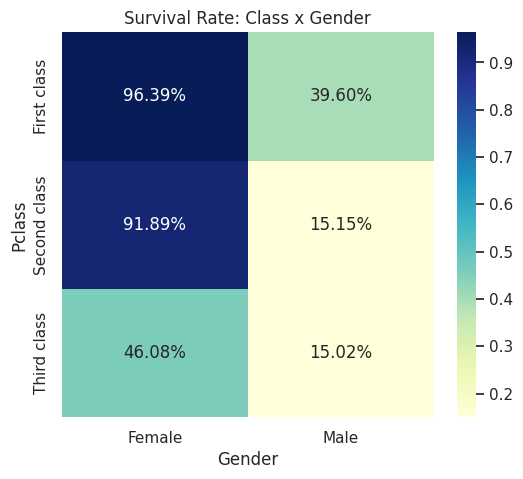

In [1]:
plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='YlGnBu')
plt.title('Survival Rate: Class x Gender')
plt.show()

## 9. Correlation Analysis

In [1]:
numeric_cols = ['Age','Family','Fare','Survived_num']
corr = df[numeric_cols].corr()
corr

                   Age    Family      Fare  Survived_num
Age           1.000000 -0.300680  0.093132     -0.082260
Family       -0.300680  1.000000  0.206502      0.045068
Fare          0.093132  0.206502  1.000000      0.266100
Survived_num -0.082260  0.045068  0.266100      1.000000

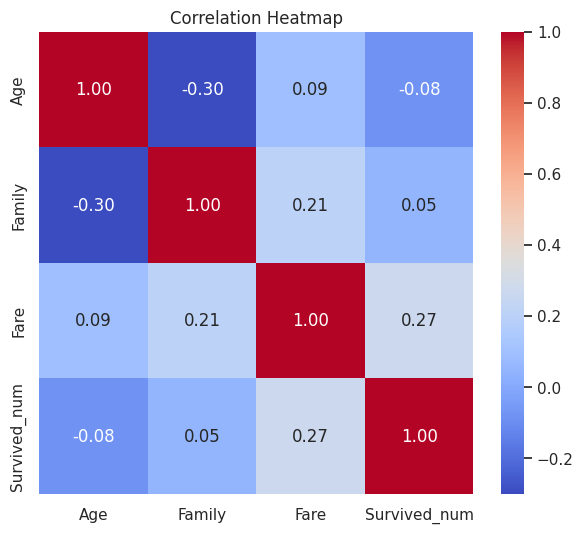

In [1]:
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 10. Summary

- **712 passengers**, no missing values or duplicates, but `Pclass` and `Embarked` had data-entry inconsistencies (capitalization and a typo) that were cleaned before analysis.
- **Overall survival rate: 40.45%** (288 survived, 424 did not).
- **Gender is the single strongest survival factor**: women survived at a dramatically higher rate than men across every class.
- **Passenger class matters heavily**: First-class passengers had far higher survival odds than Third-class, and this holds within each gender.
- The **Class × Gender breakdown** is stark: first- and second-class women survived at over 90%, while third-class men survived at only ~15%.
- **Fare correlates positively with survival** (0.27) — wealthier/higher-class passengers had better odds.
- **Family size has a non-linear relationship with survival**: traveling with 1-3 family members gave better odds than traveling completely alone, but very large families (5+) had the lowest survival rates of all — likely reflecting both social dynamics and lower-class, larger families traveling together.